# w_loss_1_2345 Binary Classifier - 1-layer MLP

This local notebook uses the same input features and 1-layer MLP structure as the provided notebook, but it does not oversample confidence 1 and does not add Gaussian noise.

Binary labels:
- 0: confidence 1
- 1: confidence 2, 3, 4, 5

Loss weighting:
- confidence 1 samples receive inverse-frequency sample weights in the training loss.
- validation/test remain unchanged and unweighted.

Use this experiment to check whether poor confidence classification is mainly caused by class imbalance or by weak feature separability.


In [1]:
# =====================================================
# 1. IMPORTS AND REPRODUCIBILITY
# =====================================================
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from IPython.display import display, Image
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)


DEVICE: cuda


In [2]:
# =====================================================
# 2. LOCAL PATH SETTINGS
# =====================================================
from pathlib import Path

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "metadata" / "BSD10k_metadata.csv").is_file():
            return candidate
    raise FileNotFoundError(
        "Could not find data/metadata/BSD10k_metadata.csv. "
        "Run this notebook from the Dcase baseline project folder or one of its subfolders."
    )

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
FEATURE_DIR = DATA_DIR / "features"

METADATA_CSV = DATA_DIR / "metadata" / "BSD10k_metadata.csv"
AUDIO_EMB_DIR = FEATURE_DIR / "clap_audio_embeddings"
TEXT_EMB_DIR = FEATURE_DIR / "clap_text_embeddings"

# Column names
SOUND_ID_COL = "sound_id"
CLASS_COL = "class"
CONFIDENCE_COL = "confidence"

OUTPUT_BASE_DIR = PROJECT_ROOT / "outputs" / "up_sampling_confi4_binary_w_loss"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("METADATA_CSV:", METADATA_CSV)
print("AUDIO_EMB_DIR:", AUDIO_EMB_DIR)
print("TEXT_EMB_DIR:", TEXT_EMB_DIR)
print("OUTPUT_BASE_DIR:", OUTPUT_BASE_DIR)


PROJECT_ROOT: c:\Users\solok\Desktop\Dcase baseline
METADATA_CSV: c:\Users\solok\Desktop\Dcase baseline\data\metadata\BSD10k_metadata.csv
AUDIO_EMB_DIR: c:\Users\solok\Desktop\Dcase baseline\data\features\clap_audio_embeddings
TEXT_EMB_DIR: c:\Users\solok\Desktop\Dcase baseline\data\features\clap_text_embeddings
OUTPUT_BASE_DIR: c:\Users\solok\Desktop\Dcase baseline\outputs\up_sampling_confi4_binary_w_loss


In [3]:
# =====================================================
# 4. EXPERIMENT SETTINGS
# =====================================================
TEST_SIZE = 0.20
VALID_SIZE = 0.20
BATCH_SIZE = 256
NUM_EPOCHS = 120
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 15

# No oversampling and no Gaussian noise in this weighted-loss experiment.
# The original train distribution is preserved; only selected confidence samples get larger loss weights.
USE_AUDIO_EMB = True
USE_TEXT_EMB = True
USE_CLASS_ONEHOT = True
USE_DESCRIPTION_LENGTH = False

ORIGINAL_LABELS = [1, 2, 3, 4, 5]
BINARY_LABELS = [0, 1]


In [4]:
# =====================================================
# BINARY LABEL AND WEIGHT SETTINGS
# =====================================================
EXPERIMENT_NAME = "w_loss_1_2345_1layer_mlp_binary_classifier"
NEGATIVE_CONFIDENCES = [1]
POSITIVE_CONFIDENCES = [2, 3, 4, 5]
WEIGHTED_CONFIDENCES = [1]
BINARY_LABEL_NAMES = {
    0: "confidence1",
    1: "confidence2345",
}

print("Binary task:", BINARY_LABEL_NAMES[0], "vs", BINARY_LABEL_NAMES[1])
print("0:", NEGATIVE_CONFIDENCES)
print("1:", POSITIVE_CONFIDENCES)
print("Weighted original confidences:", WEIGHTED_CONFIDENCES)


Binary task: confidence1 vs confidence2345
0: [1]
1: [2, 3, 4, 5]
Weighted original confidences: [1]


In [5]:
# =====================================================
# 5. DATA LOADING, SPLIT, AND WEIGHT HELPERS
# =====================================================
def verify_local_feature_dirs():
    missing = []
    for name, path in [
        ("audio embeddings", Path(AUDIO_EMB_DIR)),
        ("text embeddings", Path(TEXT_EMB_DIR)),
    ]:
        if not path.is_dir() or not any(path.glob("*.npy")):
            missing.append(f"{name}: {path}")

    if missing:
        raise FileNotFoundError(
            "Missing local feature directories or .npy files:\n"
            + "\n".join(missing)
        )


def finite_float32(x):
    return np.nan_to_num(
        np.asarray(x, dtype=np.float32),
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    ).astype(np.float32)


def clean_metadata(df):
    df = df.copy()
    df[SOUND_ID_COL] = df[SOUND_ID_COL].astype(str).str.strip()
    df[CLASS_COL] = df[CLASS_COL].astype(str).str.strip()
    df[CONFIDENCE_COL] = pd.to_numeric(df[CONFIDENCE_COL], errors="coerce")
    df = df[df[CONFIDENCE_COL].isin(ORIGINAL_LABELS)].copy()
    df[CONFIDENCE_COL] = df[CONFIDENCE_COL].astype(int)

    # Follow the existing repository convention: remove class_idx values ending in 99 or 00 when present.
    if "class_idx" in df.columns:
        class_idx = df["class_idx"].astype(str).str.strip()
        keep = ~((class_idx.str.len() == 3) & (class_idx.str.endswith("99") | class_idx.str.endswith("00")))
        df = df[keep].copy()

    return df.reset_index(drop=True)


def one_hot(values, categories):
    category_to_idx = {category: idx for idx, category in enumerate(categories)}
    arr = np.zeros((len(values), len(categories)), dtype=np.float32)
    for row_idx, value in enumerate(values):
        arr[row_idx, category_to_idx[str(value)]] = 1.0
    return arr


def load_embedding(path):
    return finite_float32(np.load(path).reshape(-1))


def build_dataset():
    verify_local_feature_dirs()

    meta = clean_metadata(pd.read_csv(METADATA_CSV))
    audio_dir = Path(AUDIO_EMB_DIR)
    text_dir = Path(TEXT_EMB_DIR)

    kept_rows = []
    audio_rows = []
    text_rows = []

    for _, row in meta.iterrows():
        sound_id = str(row[SOUND_ID_COL])
        audio_path = audio_dir / f"{sound_id}.npy"
        text_path = text_dir / f"{sound_id}.npy"
        if audio_path.is_file() and text_path.is_file():
            kept_rows.append(row)
            audio_rows.append(load_embedding(audio_path))
            text_rows.append(load_embedding(text_path))

    df = pd.DataFrame(kept_rows).reset_index(drop=True)
    audio = finite_float32(np.vstack(audio_rows))
    text = finite_float32(np.vstack(text_rows))

    categories = sorted(df[CLASS_COL].astype(str).unique().tolist())
    feature_parts = []
    noise_slices = []
    start = 0

    if USE_AUDIO_EMB:
        feature_parts.append(audio)
        noise_slices.append(slice(start, start + audio.shape[1]))
        start += audio.shape[1]
        print("audio:", audio.shape)

    if USE_TEXT_EMB:
        feature_parts.append(text)
        noise_slices.append(slice(start, start + text.shape[1]))
        start += text.shape[1]
        print("text:", text.shape)

    if USE_CLASS_ONEHOT:
        class_oh = one_hot(df[CLASS_COL].astype(str).tolist(), categories)
        feature_parts.append(class_oh)
        start += class_oh.shape[1]
        print("class_onehot:", class_oh.shape)

    if USE_DESCRIPTION_LENGTH:
        desc = df["description"] if "description" in df.columns else pd.Series([""] * len(df))
        desc_len = desc.fillna("").astype(str).str.len().to_numpy(dtype=np.float32).reshape(-1, 1)
        feature_parts.append(desc_len)
        start += 1
        print("description_length:", desc_len.shape)

    X = finite_float32(np.concatenate(feature_parts, axis=1))
    y_conf = df[CONFIDENCE_COL].to_numpy(dtype=np.int64)

    noise_mask = np.zeros(X.shape[1], dtype=bool)
    for s in noise_slices:
        noise_mask[s] = True

    print("samples:", len(df), "features:", X.shape[1])
    print("\nOriginal confidence distribution")
    display(pd.Series(y_conf).value_counts().reindex(ORIGINAL_LABELS, fill_value=0).rename("full_data_confidence_count"))
    return df, X, y_conf, noise_mask, categories


def make_splits(y_conf):
    # Stratify by the original 1-5 confidence values so all splits keep the same confidence ratio.
    idx = np.arange(len(y_conf))
    train_idx, temp_idx = train_test_split(
        idx,
        test_size=TEST_SIZE + VALID_SIZE,
        random_state=SEED,
        stratify=y_conf,
    )
    relative_test_size = TEST_SIZE / (TEST_SIZE + VALID_SIZE)
    valid_idx, test_idx = train_test_split(
        temp_idx,
        test_size=relative_test_size,
        random_state=SEED,
        stratify=y_conf[temp_idx],
    )
    return train_idx, valid_idx, test_idx


def to_binary_labels(y_conf):
    y_bin = np.isin(y_conf, POSITIVE_CONFIDENCES).astype(np.int64)
    return y_bin


def confidence_distribution_table(y_conf, split_name):
    return pd.Series(y_conf).value_counts().reindex(ORIGINAL_LABELS, fill_value=0).astype(int).rename(split_name)


def binary_distribution_table(y_bin, split_name):
    return pd.Series(y_bin).value_counts().reindex(BINARY_LABELS, fill_value=0).astype(int).rename(split_name)



def build_sample_weights(y_train_conf):
    counts = pd.Series(y_train_conf).value_counts().reindex(ORIGINAL_LABELS, fill_value=0).astype(int)
    n_train = int(len(y_train_conf))
    n_original_classes = len(ORIGINAL_LABELS)

    weight_by_confidence = {label: 1.0 for label in ORIGINAL_LABELS}
    plan_rows = []
    for label in ORIGINAL_LABELS:
        count = int(counts.loc[label])
        weighted = label in WEIGHTED_CONFIDENCES
        if weighted:
            if count <= 0:
                raise ValueError(f"confidence {label} count is zero in the train split.")
            weight = n_train / (n_original_classes * count)
        else:
            weight = 1.0
        weight_by_confidence[label] = float(weight)
        plan_rows.append({
            "confidence": label,
            "train_count": count,
            "is_weighted": weighted,
            "loss_weight": float(weight),
        })

    sample_weights = np.asarray([weight_by_confidence[int(label)] for label in y_train_conf], dtype=np.float32)
    weight_plan = pd.DataFrame(plan_rows)
    return sample_weights, weight_plan


def sample_confidence1_to_confidence4(X_train, y_train_conf, noise_mask):
    rng = np.random.default_rng(SEED)
    before = pd.Series(y_train_conf).value_counts().reindex(ORIGINAL_LABELS, fill_value=0).astype(int)
    conf1_n = int(before.loc[1])
    conf4_n = int(before.loc[4])
    if conf1_n <= 0:
        raise ValueError("confidence 1 count is zero in the train split.")
    if conf4_n <= 0:
        raise ValueError("confidence 4 count is zero in the train split.")

    keep_pos = np.arange(len(y_train_conf))
    x_parts = [X_train[keep_pos].copy()]
    y_conf_parts = [y_train_conf[keep_pos].copy()]
    aug_flags = [False] * len(keep_pos)

    conf1_pos = np.flatnonzero(y_train_conf == 1)
    duplicate_pos = np.array([], dtype=np.int64)
    removed_original_pos = np.array([], dtype=np.int64)

    if conf1_n < conf4_n:
        duplicate_pos = rng.choice(conf1_pos, size=conf4_n - conf1_n, replace=True)
        x_dup = X_train[duplicate_pos].copy()
        noise = rng.normal(loc=0.0, scale=NOISE_STD, size=x_dup[:, noise_mask].shape).astype(np.float32)
        x_dup[:, noise_mask] = x_dup[:, noise_mask] + noise
        x_parts.append(x_dup)
        y_conf_parts.append(y_train_conf[duplicate_pos].copy())
        aug_flags.extend([True] * len(x_dup))
        action = "confidence1_upsample_with_noise_to_confidence4_count"
    elif conf1_n > conf4_n and DOWNSAMPLE_CONFIDENCE1_IF_ABOVE_CONFIDENCE4:
        chosen_conf1 = rng.choice(conf1_pos, size=conf4_n, replace=False)
        keep_mask = np.ones(len(y_train_conf), dtype=bool)
        drop_conf1 = np.setdiff1d(conf1_pos, chosen_conf1, assume_unique=False)
        keep_mask[drop_conf1] = False
        x_parts = [X_train[keep_mask].copy()]
        y_conf_parts = [y_train_conf[keep_mask].copy()]
        aug_flags = [False] * int(keep_mask.sum())
        removed_original_pos = drop_conf1
        action = "confidence1_downsample_to_confidence4_count"
    elif conf1_n > conf4_n:
        action = "confidence1_kept_original_above_confidence4_count"
    else:
        action = "confidence1_already_equal_confidence4_count"

    X_sampled = finite_float32(np.vstack(x_parts))
    y_conf_sampled = np.concatenate(y_conf_parts).astype(np.int64)
    aug_flags = np.asarray(aug_flags, dtype=bool)

    order = rng.permutation(len(y_conf_sampled))
    X_sampled = X_sampled[order]
    y_conf_sampled = y_conf_sampled[order]
    aug_flags = aug_flags[order]

    after = pd.Series(y_conf_sampled).value_counts().reindex(ORIGINAL_LABELS, fill_value=0).astype(int)
    plan = pd.DataFrame([{
        "class_adjusted": "confidence_1",
        "confidence1_before": conf1_n,
        "confidence4_train_target": conf4_n,
        "added_noisy_confidence1_duplicates": int(len(duplicate_pos)),
        "removed_confidence1_originals": int(len(removed_original_pos)),
        "confidence1_after": int(after.loc[1]),
        "confidence4_after": int(after.loc[4]),
        "action": action,
    }])
    return X_sampled, y_conf_sampled, aug_flags, plan


def make_loader(X_np, y_np, batch_size=BATCH_SIZE, shuffle=False):
    x_tensor = torch.from_numpy(finite_float32(X_np))
    y_tensor = torch.from_numpy(y_np.astype(np.int64))
    dataset = TensorDataset(x_tensor, y_tensor)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, num_workers=0, pin_memory=torch.cuda.is_available())


def classification_metrics(y_true, y_pred_class, mae_score=None):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred_class,
        labels=BINARY_LABELS,
        average="macro",
        zero_division=0,
    )
    mae_source = y_pred_class if mae_score is None else mae_score
    return {
        "accuracy": float(accuracy_score(y_true, y_pred_class)),
        "macro_precision": float(precision),
        "macro_recall": float(recall),
        "macro_f1": float(f1),
        "mae": float(mean_absolute_error(y_true, mae_source)),
    }


def save_loss_curve(history, title, out_path):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(history["epoch"], history["train_loss"], label="train loss")
    ax.plot(history["epoch"], history["val_loss"], label="validation loss")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    fig.savefig(out_path, dpi=160)
    plt.show()


def save_confusion(y_true, y_pred, title, out_path):
    cm = confusion_matrix(y_true, y_pred, labels=BINARY_LABELS)
    cm_norm = cm.astype(np.float32) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

    fig, ax = plt.subplots(figsize=(5.6, 4.8))
    im = ax.imshow(cm_norm, vmin=0.0, vmax=1.0, cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Predicted binary label")
    ax.set_ylabel("True binary label")
    ax.set_xticks(range(len(BINARY_LABELS)), [BINARY_LABEL_NAMES[i] for i in BINARY_LABELS])
    ax.set_yticks(range(len(BINARY_LABELS)), [BINARY_LABEL_NAMES[i] for i in BINARY_LABELS])
    for i in range(len(BINARY_LABELS)):
        for j in range(len(BINARY_LABELS)):
            ax.text(j, i, f"{cm_norm[i, j] * 100:.1f}%", ha="center", va="center", fontsize=9)
    fig.colorbar(im, ax=ax)
    fig.tight_layout()
    fig.savefig(out_path, dpi=160)
    plt.show()
    return cm, cm_norm


In [6]:
# =====================================================
# 6. SPLIT FIRST, THEN KEEP ORIGINAL TRAIN DISTRIBUTION
# =====================================================
df, X, y_conf, noise_mask, class_categories = build_dataset()
train_idx, valid_idx, test_idx = make_splits(y_conf)

X_train_raw = X[train_idx]
y_train_conf_raw = y_conf[train_idx]
X_valid_raw = X[valid_idx]
y_valid_conf = y_conf[valid_idx]
X_test_raw = X[test_idx]
y_test_conf = y_conf[test_idx]

y_train = to_binary_labels(y_train_conf_raw)
y_valid = to_binary_labels(y_valid_conf)
y_test = to_binary_labels(y_test_conf)

train_sample_weights, weight_plan = build_sample_weights(y_train_conf_raw)

# Fit scaler on the original train split, then transform train/valid/test.
scaler = StandardScaler()
scaler.fit(X_train_raw)
X_train = scaler.transform(X_train_raw).astype(np.float32)
X_valid = scaler.transform(X_valid_raw).astype(np.float32)
X_test = scaler.transform(X_test_raw).astype(np.float32)

print("split sizes:", len(train_idx), len(valid_idx), len(test_idx))
print("train rows kept original:", len(X_train))

print()
print("Original confidence distribution by split")
split_conf_counts = pd.concat([
    confidence_distribution_table(y_conf, "full"),
    confidence_distribution_table(y_train_conf_raw, "train"),
    confidence_distribution_table(y_valid_conf, "validation"),
    confidence_distribution_table(y_test_conf, "test"),
], axis=1)
display(split_conf_counts)
print("These are the approximately fair stratified split counts for confidence 1, 2, 3, 4, 5.")

print()
print("Original-confidence loss weight plan")
display(weight_plan)

print()
print("Binary distribution")
binary_counts = pd.concat([
    binary_distribution_table(y_train, "train"),
    binary_distribution_table(y_valid, "validation"),
    binary_distribution_table(y_test, "test"),
], axis=1)
binary_counts.index = [BINARY_LABEL_NAMES[i] for i in binary_counts.index]
display(binary_counts)

print()
print("Train sample weight summary by original confidence")
weight_summary = pd.DataFrame({
    "confidence": y_train_conf_raw,
    "binary_label": y_train,
    "sample_weight": train_sample_weights,
}).groupby(["confidence", "binary_label"]).agg(
    count=("sample_weight", "size"),
    sample_weight=("sample_weight", "first"),
).reset_index()
display(weight_summary)


audio: (10956, 512)
text: (10956, 512)
class_onehot: (10956, 23)
samples: 10956 features: 1047

Original confidence distribution


1     106
2     749
3    3280
4    6045
5     776
Name: full_data_confidence_count, dtype: int64

split sizes: 6573 2191 2192
train rows kept original: 6573

Original confidence distribution by split


,full,train,validation,test
1,106,64,21,21
2,749,449,150,150
3,3280,1968,656,656
4,6045,3627,1209,1209
5,776,465,155,156


These are the approximately fair stratified split counts for confidence 1, 2, 3, 4, 5.

Original-confidence loss weight plan


,confidence,train_count,is_weighted,loss_weight
0,1,64,True,20.540625
1,2,449,False,1.000000
2,3,1968,False,1.000000
3,4,3627,False,1.000000
4,5,465,False,1.000000



Binary distribution


,train,validation,test
confidence1,64,21,21
confidence2345,6509,2170,2171



Train sample weight summary by original confidence


,confidence,binary_label,count,sample_weight
0,1,0,64,20.540625
1,2,1,449,1.000000
2,3,1,1968,1.000000
3,4,1,3627,1.000000
4,5,1,465,1.000000


[001/120] train_loss=0.7746 val_loss=0.7225 val_f1=0.3596 val_mae=0.4655
[010/120] train_loss=0.5343 val_loss=0.5225 val_f1=0.4709 val_mae=0.1981
[020/120] train_loss=0.4336 val_loss=0.3962 val_f1=0.5154 val_mae=0.0940
[030/120] train_loss=0.3804 val_loss=0.3084 val_f1=0.5319 val_mae=0.0607
[040/120] train_loss=0.3530 val_loss=0.2636 val_f1=0.5441 val_mae=0.0552
[050/120] train_loss=0.3126 val_loss=0.2310 val_f1=0.5363 val_mae=0.0502
[060/120] train_loss=0.2917 val_loss=0.2029 val_f1=0.5317 val_mae=0.0475
[070/120] train_loss=0.2850 val_loss=0.1819 val_f1=0.5600 val_mae=0.0393
[080/120] train_loss=0.2860 val_loss=0.1768 val_f1=0.5332 val_mae=0.0461
[090/120] train_loss=0.2498 val_loss=0.1561 val_f1=0.5576 val_mae=0.0356
[100/120] train_loss=0.2365 val_loss=0.1484 val_f1=0.5448 val_mae=0.0374
[110/120] train_loss=0.2637 val_loss=0.1431 val_f1=0.5325 val_mae=0.0393
[120/120] train_loss=0.2536 val_loss=0.1367 val_f1=0.5462 val_mae=0.0365


,split,accuracy,macro_precision,macro_recall,macro_f1,mae
0,validation,0.967138,0.529911,0.582565,0.541632,0.032862
1,test,0.969891,0.525208,0.560374,0.534014,0.030109


Validation classification report
                precision    recall  f1-score   support

   confidence1       0.07      0.19      0.10        21
confidence2345       0.99      0.97      0.98      2170

      accuracy                           0.97      2191
     macro avg       0.53      0.58      0.54      2191
  weighted avg       0.98      0.97      0.97      2191

Test classification report
                precision    recall  f1-score   support

   confidence1       0.06      0.14      0.08        21
confidence2345       0.99      0.98      0.98      2171

      accuracy                           0.97      2192
     macro avg       0.53      0.56      0.53      2192
  weighted avg       0.98      0.97      0.98      2192

Validation classification report dataframe


,precision,recall,f1-score,support
confidence1,0.067797,0.190476,0.100000,21.000000
confidence2345,0.992026,0.974654,0.983264,2170.000000
accuracy,0.967138,0.967138,0.967138,0.967138
macro avg,0.529911,0.582565,0.541632,2191.000000
weighted avg,0.983168,0.967138,0.974798,2191.000000


Test classification report dataframe


,precision,recall,f1-score,support
confidence1,0.058824,0.142857,0.083333,21.000000
confidence2345,0.991593,0.977890,0.984694,2171.000000
accuracy,0.969891,0.969891,0.969891,0.969891
macro avg,0.525208,0.560374,0.534014,2192.000000
weighted avg,0.982657,0.969891,0.976059,2192.000000


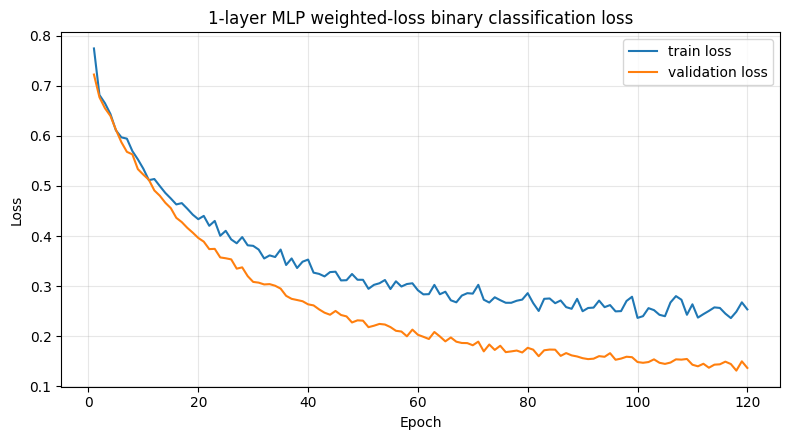

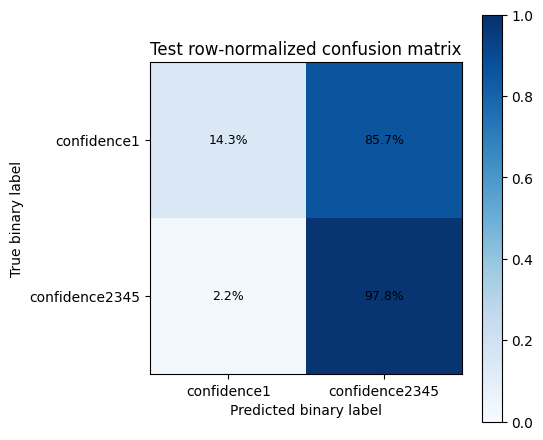

Saved to: c:\Users\solok\Desktop\Dcase baseline\outputs\up_sampling_confi4_binary_w_loss\w_loss_1_2345_1layer_mlp_binary_classifier


In [7]:
# =====================================================
# 7. 1-LAYER MLP BINARY CLASSIFICATION
# =====================================================
OUTPUT_DIR = Path(OUTPUT_BASE_DIR) / EXPERIMENT_NAME
REPORT_DIR = OUTPUT_DIR / "reports"
PLOT_DIR = OUTPUT_DIR / "plots"
PRED_DIR = OUTPUT_DIR / "predictions"
for path in [REPORT_DIR, PLOT_DIR, PRED_DIR]:
    path.mkdir(parents=True, exist_ok=True)

weight_plan.to_csv(REPORT_DIR / "original_confidence_loss_weight_plan.csv", index=False)

class OneLayerMLPBinaryClassifier(nn.Module):
    def __init__(self, input_dim, num_classes=2, dropout=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(input_dim, num_classes),
        )

    def forward(self, x):
        return self.net(x)


@torch.no_grad()
def predict_classifier(model, X_np, y_np):
    loader = make_loader(X_np, y_np, shuffle=False)
    model.eval()
    pred_chunks = []
    true_chunks = []
    prob_chunks = []
    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        logits = model(xb)
        prob = torch.softmax(logits, dim=1).detach().cpu().numpy()
        pred = prob.argmax(axis=1).astype(np.int64)
        pred_chunks.append(pred)
        true_chunks.append(yb.numpy().astype(np.int64))
        prob_chunks.append(prob)
    return np.concatenate(true_chunks), np.concatenate(pred_chunks), np.vstack(prob_chunks)


model = OneLayerMLPBinaryClassifier(input_dim=X_train.shape[1]).to(DEVICE)
criterion = nn.CrossEntropyLoss(reduction="none")
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

train_dataset = TensorDataset(
    torch.from_numpy(finite_float32(X_train)),
    torch.from_numpy(y_train.astype(np.int64)),
    torch.from_numpy(train_sample_weights.astype(np.float32)),
)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)
valid_loader = make_loader(X_valid, y_valid, shuffle=False)

best_state = None
best_val_loss = float("inf")
bad_epochs = 0
history_rows = []

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    train_loss_sum = 0.0
    train_weight_sum = 0.0
    for xb, yb, wb in train_loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)
        wb = wb.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss_each = criterion(logits, yb)
        loss = (loss_each * wb).sum() / wb.sum().clamp_min(1e-8)
        loss.backward()
        optimizer.step()
        train_loss_sum += float((loss_each * wb).sum().item())
        train_weight_sum += float(wb.sum().item())

    model.eval()
    val_loss_sum = 0.0
    val_seen = 0
    with torch.no_grad():
        for xb, yb in valid_loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)
            logits = model(xb)
            loss_each = criterion(logits, yb)
            val_loss_sum += float(loss_each.sum().item())
            val_seen += xb.size(0)

    train_loss = train_loss_sum / max(train_weight_sum, 1e-8)
    val_loss = val_loss_sum / max(val_seen, 1)
    val_true, val_pred, _ = predict_classifier(model, X_valid, y_valid)
    val_metrics = classification_metrics(val_true, val_pred)

    history_rows.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        **{f"val_{k}": v for k, v in val_metrics.items()},
    })

    if epoch == 1 or epoch % 10 == 0:
        print(f"[{epoch:03d}/{NUM_EPOCHS}] train_loss={train_loss:.4f} val_loss={val_loss:.4f} val_f1={val_metrics['macro_f1']:.4f} val_mae={val_metrics['mae']:.4f}")

    if val_loss < best_val_loss - 1e-6:
        best_val_loss = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        bad_epochs = 0
    else:
        bad_epochs += 1
        if bad_epochs >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

model.load_state_dict(best_state)
history = pd.DataFrame(history_rows)
history.to_csv(REPORT_DIR / "history.csv", index=False)
try:
    torch.save(model.state_dict(), OUTPUT_DIR / "best_model.pth")
except Exception as e:
    print("Model save skipped:", type(e).__name__, e)

val_true, val_pred, val_prob = predict_classifier(model, X_valid, y_valid)
test_true, test_pred, test_prob = predict_classifier(model, X_test, y_test)
val_metrics = classification_metrics(val_true, val_pred)
test_metrics = classification_metrics(test_true, test_pred)

summary = pd.DataFrame([
    {"split": "validation", **val_metrics},
    {"split": "test", **test_metrics},
])
summary.to_csv(REPORT_DIR / "metrics_summary.csv", index=False)
display(summary)


classification_target_names = [BINARY_LABEL_NAMES[i] for i in BINARY_LABELS]

print("Validation classification report")
print(classification_report(
    val_true,
    val_pred,
    labels=BINARY_LABELS,
    target_names=classification_target_names,
    zero_division=0,
))

print("Test classification report")
print(classification_report(
    test_true,
    test_pred,
    labels=BINARY_LABELS,
    target_names=classification_target_names,
    zero_division=0,
))

val_report_df = pd.DataFrame(classification_report(
    val_true,
    val_pred,
    labels=BINARY_LABELS,
    target_names=classification_target_names,
    zero_division=0,
    output_dict=True,
)).T

test_report_df = pd.DataFrame(classification_report(
    test_true,
    test_pred,
    labels=BINARY_LABELS,
    target_names=classification_target_names,
    zero_division=0,
    output_dict=True,
)).T

val_report_df.to_csv(REPORT_DIR / "validation_classification_report.csv")
test_report_df.to_csv(REPORT_DIR / "test_classification_report.csv")

print("Validation classification report dataframe")
display(val_report_df)

print("Test classification report dataframe")
display(test_report_df)

save_loss_curve(history, "1-layer MLP weighted-loss binary classification loss", PLOT_DIR / "train_val_loss.png")

cm, cm_norm = save_confusion(test_true, test_pred, "Test row-normalized confusion matrix", PLOT_DIR / "test_confusion_row_normalized.png")
pd.DataFrame(cm, index=[f"true_{BINARY_LABEL_NAMES[i]}" for i in BINARY_LABELS], columns=[f"pred_{BINARY_LABEL_NAMES[i]}" for i in BINARY_LABELS]).to_csv(REPORT_DIR / "test_confusion_counts.csv")
pd.DataFrame(cm_norm, index=[f"true_{BINARY_LABEL_NAMES[i]}" for i in BINARY_LABELS], columns=[f"pred_{BINARY_LABEL_NAMES[i]}" for i in BINARY_LABELS]).to_csv(REPORT_DIR / "test_confusion_row_normalized.csv")

pred_out = df.iloc[test_idx][[SOUND_ID_COL, CLASS_COL, CONFIDENCE_COL]].copy()
pred_out["true_binary_label"] = test_true
pred_out["predicted_binary_label"] = test_pred
pred_out["true_binary_name"] = [BINARY_LABEL_NAMES[int(i)] for i in test_true]
pred_out["predicted_binary_name"] = [BINARY_LABEL_NAMES[int(i)] for i in test_pred]
for i, label in enumerate(BINARY_LABELS):
    pred_out[f"prob_{BINARY_LABEL_NAMES[label]}"] = test_prob[:, i]
pred_out.to_csv(PRED_DIR / "test_predictions.csv", index=False)

print("Saved to:", OUTPUT_DIR)


,split,accuracy,macro_precision,macro_recall,macro_f1,mae
0,validation,0.967138,0.529911,0.582565,0.541632,0.032862
1,test,0.969891,0.525208,0.560374,0.534014,0.030109


,precision,recall,f1-score,support
confidence1,0.067797,0.190476,0.100000,21.000000
confidence2345,0.992026,0.974654,0.983264,2170.000000
accuracy,0.967138,0.967138,0.967138,0.967138
macro avg,0.529911,0.582565,0.541632,2191.000000
weighted avg,0.983168,0.967138,0.974798,2191.000000


,precision,recall,f1-score,support
confidence1,0.058824,0.142857,0.083333,21.000000
confidence2345,0.991593,0.977890,0.984694,2171.000000
accuracy,0.969891,0.969891,0.969891,0.969891
macro avg,0.525208,0.560374,0.534014,2192.000000
weighted avg,0.982657,0.969891,0.976059,2192.000000


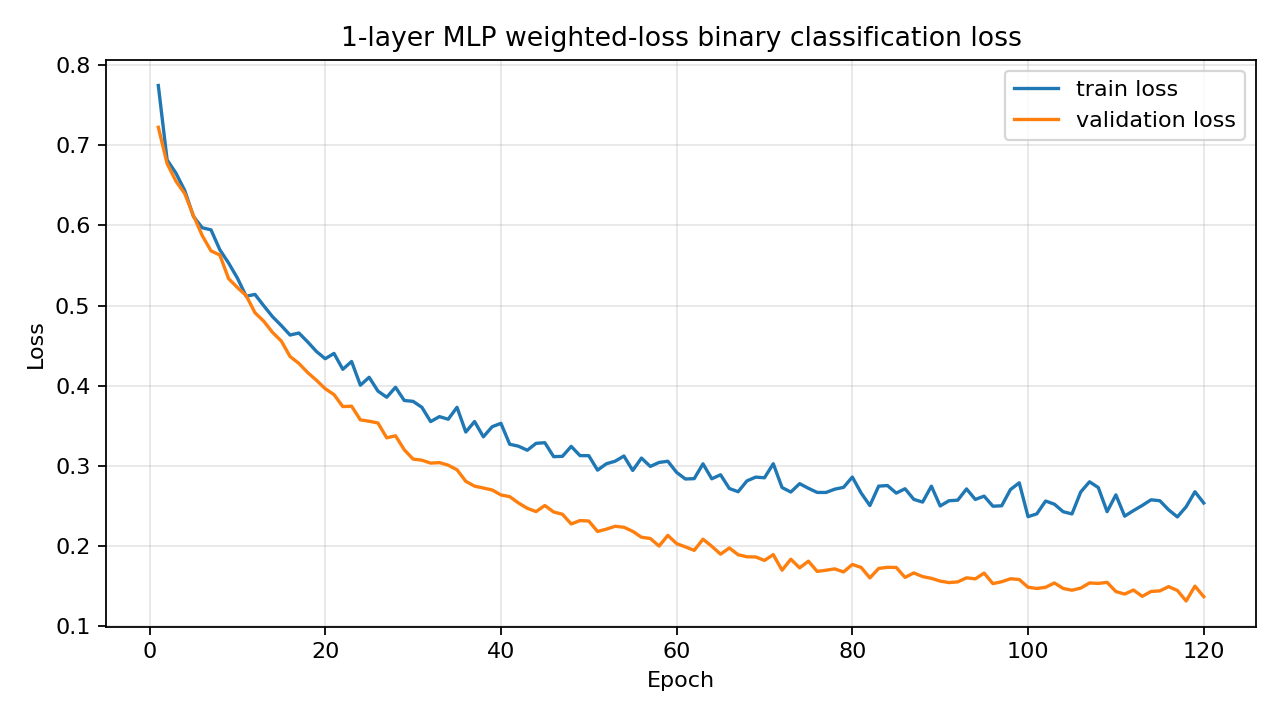

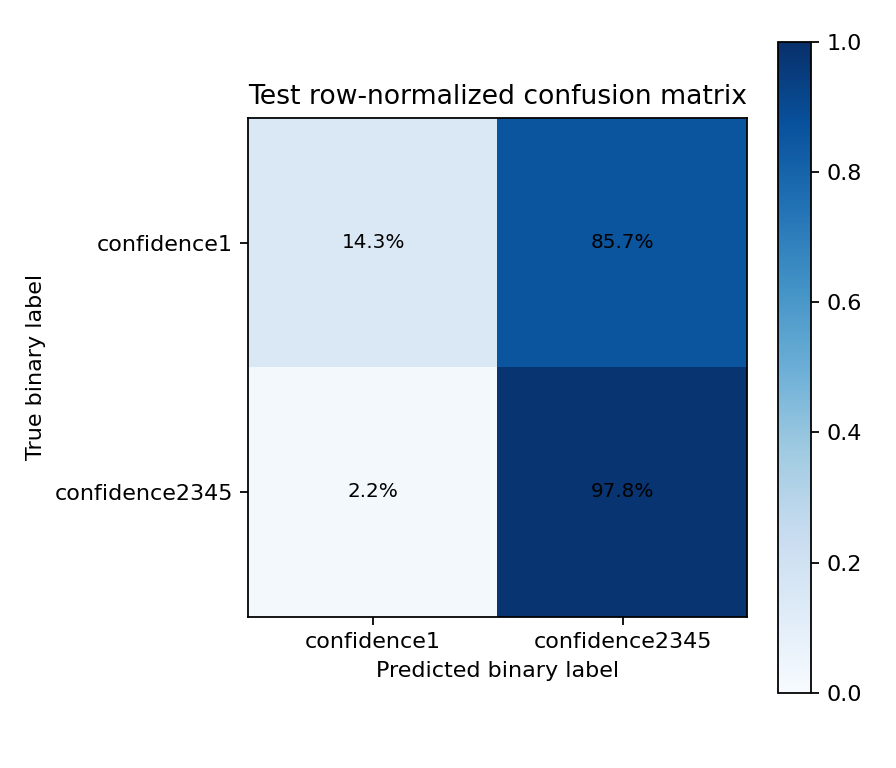

In [8]:
# =====================================================
# 8. RESULT FILES
# =====================================================
display(pd.read_csv(REPORT_DIR / "metrics_summary.csv"))
display(pd.read_csv(REPORT_DIR / "validation_classification_report.csv", index_col=0))
display(pd.read_csv(REPORT_DIR / "test_classification_report.csv", index_col=0))
display(Image(filename=str(PLOT_DIR / "train_val_loss.png")))
display(Image(filename=str(PLOT_DIR / "test_confusion_row_normalized.png")))
